Benchmarking LLM Performance using realworld metrics: Latency, Throughput, and Memory Usage, Perplexity (PPL)

##### Latency and Throughput

- Latency = total time taken to process a request. Throughput = number of requests processed in a given time.
- Throughput is inversely proportional to latency. If latency increases, throughput decreases, and vice versa.

- Throughput = tokens/second or requests/second


- Testing above metrics when changing - prompt length, numerical precision, cache usage.

| max_new_tokens | Approx Latency per Request | Requests/sec (Req/s) | Tokens/sec (Tok/s) |
| -------------- | -------------------------- | -------------------- | ------------------ |
| 50             | 1 sec                      | 1.0                  | 50 tok/s           |
| 100            | 2 sec                      | 0.5                  | 50 tok/s           |
| 150            | 3 sec                      | 0.33                 | 50 tok/s           |

As max_new_tokens increases:

- Latency increases (request takes longer)
- Req/s decreases (fewer requests completed per second)
- Tok/s  remains relatively constant after an initial dip if hardware utilization is good

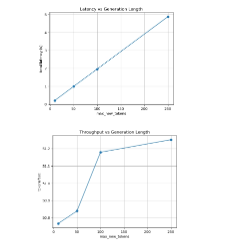

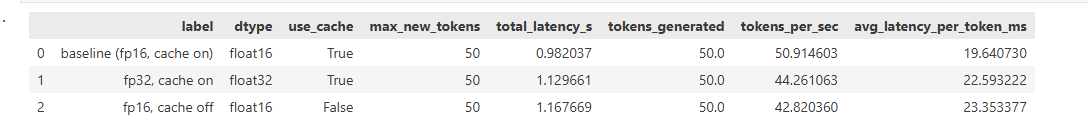

Measuring end-to-end latency reveals clear performance trade-offs: 
- longer generation lengths increase total latency, 
- disabling the KV cache severely degrades throughput, and 
- using lower precision (float16) on a GPU significantly improves performance.

we test the effect of the Key-Value (KV) cache, a crucial optimization that avoids recomputing attention scores for previous tokens in the sequence.

In [ ]:
# Select device:
# Use GPU (CUDA) if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use FP16 on GPU for faster inference and lower memory usage
# Use FP32 on CPU for compatibility
dtype = torch.float16 if device.type == "cuda" else torch.float32


# Load tokenizer
# Converts text <-> token IDs
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Load pretrained causal language model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype
)

# Move model to target device (GPU/CPU)
model.to(device)

# Set model to evaluation mode # Disables dropout and training-specific layers
model.eval()


# Tokenize input text # return_tensors="pt" returns PyTorch tensors
inputs = tokenizer(text, return_tensors="pt")

# Labels are needed for loss/perplexity calculation # Shifted internally by causal LM
inputs["labels"] = inputs["input_ids"].clone()

# Get input sequence length
input_len = inputs["input_ids"].size(1)

# Reset CUDA peak memory stats before inference
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)

# Disable gradient computation for inference
with torch.no_grad():

    # Forward pass through model
    outputs = model(
        input_ids=inputs["input_ids"].to(device),

        # Attention mask ignores padding tokens
        attention_mask=(
            inputs.get("attention_mask", None).to(device)  if inputs.get("attention_mask") is not None  else None ),
        # Labels used to compute cross-entropy loss
        labels=inputs["labels"].to(device)
    )


# Synchronize GPU operations before reading memory stats
if device.type == "cuda":
    torch.cuda.synchronize()

    # Peak GPU memory used during inference
    peak_bytes = torch.cuda.max_memory_allocated(device)

    # Convert bytes -> MiB
    peak_mib = peak_bytes / 1024**2

# Function to compute perplexity from loss
# Lower perplexity = better language modeling performance
def compute_perplexity(loss: float):
    return math.exp(loss)

# Generate text from model
out = model.generate(
    input_ids,
    # Maximum new tokens to generate
    max_new_tokens=max_new_tokens,
    # KV cache speeds up autoregressive decoding
    use_cache=use_cache
)

#### Baseline

| Tokens | Peak Mem (MiB) | PPL   | Latency |
| ------ | -------------- | ----- | ------- |
| 108    | 2145.6         | 4.138 | 0.021s  |


##### Context Sweep

| Tokens | Peak Mem (MiB) | Latency |
| ------ | -------------- | ------- |
| 108    | 2145.6         | 0.021s  |
| 322    | 2216.7         | 0.049s  |
| 1071   | 2463.0         | 0.163s  |

**Observation:** More context → higher memory & latency.



##### Precision Compare

| Precision | Peak Mem (MiB) | PPL   |
| --------- | -------------- | ----- |
| FP16      | 4245.2         | 4.138 |
| FP32      | 4245.8         | 4.138 |

- PPL remains identical, Memory difference here is negligible, but in practice, FP16 can allow for larger batch sizes or models to fit in memory, which can improve throughput and latency.


#### Batch Sweep

| Batch Size | Peak Mem (MiB) |
| ---------- | -------------- |
| 1          | 2145.6         |
| 2          | 2180.5         |
| 4          | 2251.8         |

**Observation:** Higher batch size → higher GPU memory.
* **Model weights** are fixed and shared across all batches.
* **Activations/KV cache** are created per input, so they grow with batch size.
- Total memory = Model weights + (Activations/KV cache * Batch Size)

That’s why memory increases moderately as batch size increases.
